In [29]:
!pip install llama-index llama-index-embeddings-huggingface llama-index-llms-gemini nest_asyncio

In [3]:
!pip install "jedi>=0.16,<0.19"

In [8]:
import os
print(os.getcwd())

/content


In [9]:
!ls

QuestionAnswer.pdf  sample_data


In [21]:
from llama_index.core import SimpleDirectoryReader

# Load PDF or text document
documents = SimpleDirectoryReader(
    input_dir="content",
    input_files=["Nepal1.pdf"]
    ).load_data()
print(f"Loaded {len(documents)} documents.")

Loaded 1 documents.


### Fixed-Length Chunking

In [23]:
from llama_index.core.node_parser import SentenceSplitter

splitter_fixed = SentenceSplitter(chunk_size=100, chunk_overlap=0)  # No overlap
chunks_fixed = splitter_fixed.get_nodes_from_documents(documents)
print(f"Total Fixed-Length Chunks Created: {len(chunks_fixed)}")

for i in range(3):
  print(f"Chunk {i+1}\n")
  print(chunks_fixed[i].text)

Total Fixed-Length Chunks Created: 4
Chunk 1

Nepal is a landlocked country in South Asia, nestled in the lap of the mighty Himalayas 
between India and China. It is home to eight of the world's ten highest mountains, including 
Mount Everest, the tallest peak on Earth. With a population of approximately 30 million 
people, Nepal is incredibly diverse, comprising over 120 ethnic groups and more than 120 
languages.
Chunk 2

The country has a rich cultural heritage deeply influenced by Hinduism and 
Buddhism, with ancient temples, monasteries, and stupas dotting its landscape. 
Kathmandu, the capital city, is known for its historic Durbar Squares and vibrant street life. 
Nepal's economy is primarily based on agriculture, tourism, and remittances from Nepali 
workers abroad.
Chunk 3

Despite facing challenges such as political instability, poverty, and the 
devastating 2015 earthquake, the Nepali people are known for their resilience, warmth, and 
hospitality. The nation's natural beaut

### Overlapping Chunking

In [22]:
splitter_overlap = SentenceSplitter(chunk_size=100, chunk_overlap=50)  # 50-token overlap
chunks_overlap = splitter_overlap.get_nodes_from_documents(documents)
print(f"Total Overlapping Chunks Created: {len(chunks_overlap)}")

for i in range(3):
  print(f"Chunk {i+1}\n")
  print(chunks_overlap[i].text)

Total Overlapping Chunks Created: 6
Chunk 1

Nepal is a landlocked country in South Asia, nestled in the lap of the mighty Himalayas 
between India and China. It is home to eight of the world's ten highest mountains, including 
Mount Everest, the tallest peak on Earth. With a population of approximately 30 million 
people, Nepal is incredibly diverse, comprising over 120 ethnic groups and more than 120 
languages.
Chunk 2

With a population of approximately 30 million 
people, Nepal is incredibly diverse, comprising over 120 ethnic groups and more than 120 
languages. The country has a rich cultural heritage deeply influenced by Hinduism and 
Buddhism, with ancient temples, monasteries, and stupas dotting its landscape.
Chunk 3

The country has a rich cultural heritage deeply influenced by Hinduism and 
Buddhism, with ancient temples, monasteries, and stupas dotting its landscape. 
Kathmandu, the capital city, is known for its historic Durbar Squares and vibrant street life. 
Nepal's e

# Semantic Chunking (Advanced)

In [25]:
from llama_index.core.node_parser import SemanticSplitterNodeParser
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize embedding model for semantic splitting
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Create semantic chunker
semantic_splitter = SemanticSplitterNodeParser(embed_model=embed_model)
chunks_semantic = semantic_splitter.get_nodes_from_documents(documents)
print(f"Total Semantic Chunks Created: {len(chunks_semantic)}")

# Display a sample semantic chunk
print(f"\nSample semantic chunk:")
print(chunks_semantic[0].text)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Semantic Chunks Created: 2

Sample semantic chunk:
Nepal is a landlocked country in South Asia, nestled in the lap of the mighty Himalayas 
between India and China. It is home to eight of the world's ten highest mountains, including 
Mount Everest, the tallest peak on Earth. With a population of approximately 30 million 
people, Nepal is incredibly diverse, comprising over 120 ethnic groups and more than 120 
languages. 


In [30]:
for i, node in enumerate(chunks_semantic[:4]):
    print(f"Chunk {i}")
    print(node.text[:])
    print("-" * 40)

Chunk 0
Nepal is a landlocked country in South Asia, nestled in the lap of the mighty Himalayas 
between India and China. It is home to eight of the world's ten highest mountains, including 
Mount Everest, the tallest peak on Earth. With a population of approximately 30 million 
people, Nepal is incredibly diverse, comprising over 120 ethnic groups and more than 120 
languages. 
----------------------------------------
Chunk 1
The country has a rich cultural heritage deeply influenced by Hinduism and 
Buddhism, with ancient temples, monasteries, and stupas dotting its landscape. 
Kathmandu, the capital city, is known for its historic Durbar Squares and vibrant street life. 
Nepal's economy is primarily based on agriculture, tourism, and remittances from Nepali 
workers abroad. Despite facing challenges such as political instability, poverty, and the 
devastating 2015 earthquake, the Nepali people are known for their resilience, warmth, and 
hospitality. The nation's natural beauty, fro

### Comparision Comparison of Chunking Strategies

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

,Strategy,Number of Chunks,Average Chunk Length
0,Fixed-Length,4,316.5
1,Overlapping,6,351.5
2,Semantic,2,635.0


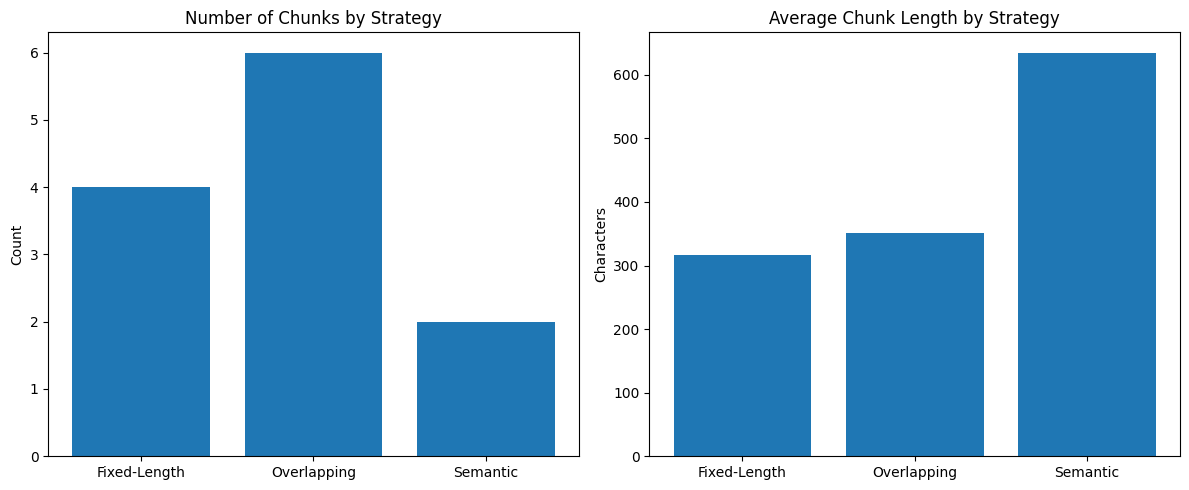

In [33]:
chunking_comparison = pd.DataFrame({
    'Strategy': ['Fixed-Length', 'Overlapping', 'Semantic'],
    'Number of Chunks': [len(chunks_fixed), len(chunks_overlap), len(chunks_semantic)],
    'Average Chunk Length': [
        sum(len(chunk.text) for chunk in chunks_fixed) / len(chunks_fixed),
        sum(len(chunk.text) for chunk in chunks_overlap) / len(chunks_overlap),
        sum(len(chunk.text) for chunk in chunks_semantic) / len(chunks_semantic)
    ]
})

display(chunking_comparison)

# Visualize the comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(chunking_comparison['Strategy'], chunking_comparison['Number of Chunks'])
plt.title('Number of Chunks by Strategy')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.bar(chunking_comparison['Strategy'], chunking_comparison['Average Chunk Length'])
plt.title('Average Chunk Length by Strategy')
plt.ylabel('Characters')

plt.tight_layout()
plt.show()

## 3. Exploring Different Embedding Models in Different Platform

Embeddings convert text into numerical vectors.

## Hugging Face embedding models

In [34]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
import time
import pandas as pd

# Initialize a list to store results
embedding_results = []

# Test different HuggingFace embedding models
hf_models = [
    "sentence-transformers/all-MiniLM-L6-v2",  # Small, fast model (384 dimensions)
    "sentence-transformers/all-mpnet-base-v2",  # More powerful (768 dimensions)
]

for model_name in hf_models:
    start_time = time.time()

    embed_model = HuggingFaceEmbedding(model_name=model_name)

    # Generate an embedding for a test sentence
    test_text = "Embeddings are numerical representations of text in vector space."
    embedding = embed_model.get_text_embedding(test_text)

    end_time = time.time()

    embedding_results.append({
        'Model': model_name,
        'Dimensions': len(embedding),
        'Generation Time (s)': end_time - start_time
    })

# Display results
embedding_df = pd.DataFrame(embedding_results)
display(embedding_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,Model,Dimensions,Generation Time (s)
0,sentence-transformers/all-MiniLM-L6-v2,384,3.559101
1,sentence-transformers/all-mpnet-base-v2,768,13.278699


## Compare and Visualize the embedding model

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


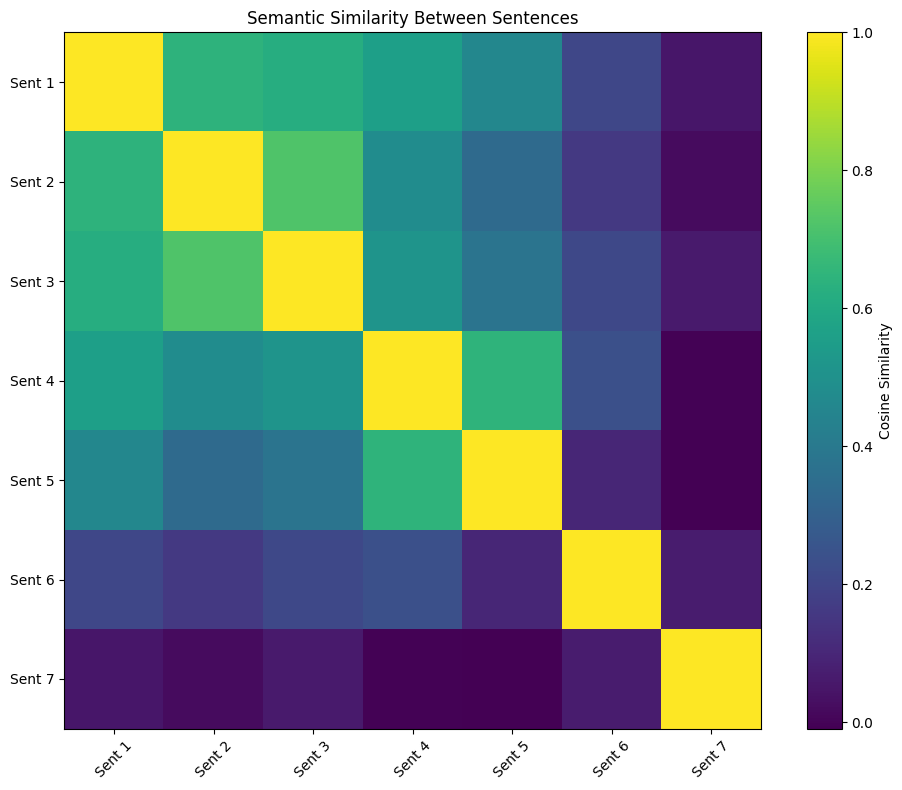

Sentence 1: Nepal is located in the Himalayas between India and China.
Sentence 2: Mount Everest is the tallest peak in Nepal.
Sentence 3: Eight of the world's highest mountains are in Nepal.
Sentence 4: Nepal has a rich Buddhist and Hindu heritage.
Sentence 5: Nepali people are known for their hospitality.
Sentence 6: Brazil is famous for its Amazon rainforest.
Sentence 7: The internet was invented in the 20th century.


In [35]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

test_sentences = [
    "Nepal is located in the Himalayas between India and China.",
    "Mount Everest is the tallest peak in Nepal.",
    "Eight of the world's highest mountains are in Nepal.",
    "Nepal has a rich Buddhist and Hindu heritage.",
    "Nepali people are known for their hospitality.",
    "Brazil is famous for its Amazon rainforest.",
    "The internet was invented in the 20th century."
]

# Create embeddings for each sentence
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
embeddings = [embed_model.get_text_embedding(sent) for sent in test_sentences]

# Calculate similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Visualize the similarity matrix
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap='viridis')
plt.colorbar(label='Cosine Similarity')
plt.xticks(np.arange(len(test_sentences)), [f"Sent {i+1}" for i in range(len(test_sentences))], rotation=45)
plt.yticks(np.arange(len(test_sentences)), [f"Sent {i+1}" for i in range(len(test_sentences))])
plt.title('Semantic Similarity Between Sentences')
plt.tight_layout()
plt.show()

# Print the sentences for reference
for i, sent in enumerate(test_sentences):
    print(f"Sentence {i+1}: {sent}")

## 4. Building a Vector Store with LlamaIndex

Build a vector database:

In [23]:
from llama_index.core import VectorStoreIndex, StorageContext
from llama_index.vector_stores.chroma import ChromaVectorStore
import chromadb

# Initialize a Chroma client
chroma_client = chromadb.Client()
chroma_collection = chroma_client.create_collection("semantic_search2")

# Create vector store
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

# Let's use overlapping chunks for our index
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Create index
index = VectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    embed_model=embed_model
)

print("Vector store created successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vector store created successfully!


In [24]:
# For Gemini API, set your API key
GOOGLE_API_KEY = "userdata.get("GOOGLE_API_KEY")"  # Replace with your actual API key
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [25]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

## 5. Querying our vector database with Gemini

In [13]:
!pip install -U llama-index-llms-google-genai

In [30]:
import os
import nest_asyncio
from llama_index.llms.google_genai import GoogleGenAI
from IPython.display import Markdown, display

nest_asyncio.apply()

# The GOOGLE_API_KEY environment variable is already set in a previous cell.
# No need to set it again here or call genai.Client directly.

# Initialize the LLM using the LlamaIndex GoogleGenAI wrapper
llm = GoogleGenAI(model="gemini-2.5-flash", api_key=os.environ["GOOGLE_API_KEY"])

# 3. Set up query engine
query_engine = index.as_query_engine(
    llm=llm,
    similarity_top_k=2
)

# 4. Your Query Function
def run_query(query_text):
    print(f"Query: {query_text}")
    print("-" * 50)

    response = query_engine.query(query_text)

    print("Response:")
    display(Markdown(response.response))

    print("\nSource Nodes:")
    for i, node in enumerate(response.source_nodes):
        print(f"\nSource {i+1} (Score: {node.score:.4f}):")
        print("-" * 40)
        print(node.text)

    return response

# 5. Run queries
queries = [
    "What is the capital of Nepal?",
    "What is the tallest mountain in Nepal",
]

for query in queries:
    run_query(query)
    print("\n" + "="*80 + "\n")

Query: What is the capital of Nepal?
--------------------------------------------------
Response:


Kathmandu is the capital city of Nepal.


Source Nodes:

Source 1 (Score: 0.5044):
----------------------------------------
Nepal is a landlocked country in South Asia, nestled in the lap of the mighty Himalayas 
between India and China. It is home to eight of the world's ten highest mountains, including 
Mount Everest, the tallest peak on Earth. With a population of approximately 30 million 
people, Nepal is incredibly diverse, comprising over 120 ethnic groups and more than 120 
languages. The country has a rich cultural heritage deeply influenced by Hinduism and 
Buddhism, with ancient temples, monasteries, and stupas dotting its landscape. 
Kathmandu, the capital city, is known for its historic Durbar Squares and vibrant street life. 
Nepal's economy is primarily based on agriculture, tourism, and remittances from Nepali 
workers abroad. Despite facing challenges such as political instability, poverty, and the 
devastating 2015 earthquake, the Nepali people are known for their resilience, warmth, and 
hospitality. The nat

Mount Everest is the tallest mountain.


Source Nodes:

Source 1 (Score: 0.5057):
----------------------------------------
Nepal is a landlocked country in South Asia, nestled in the lap of the mighty Himalayas 
between India and China. It is home to eight of the world's ten highest mountains, including 
Mount Everest, the tallest peak on Earth. With a population of approximately 30 million 
people, Nepal is incredibly diverse, comprising over 120 ethnic groups and more than 120 
languages. The country has a rich cultural heritage deeply influenced by Hinduism and 
Buddhism, with ancient temples, monasteries, and stupas dotting its landscape. 
Kathmandu, the capital city, is known for its historic Durbar Squares and vibrant street life. 
Nepal's economy is primarily based on agriculture, tourism, and remittances from Nepali 
workers abroad. Despite facing challenges such as political instability, poverty, and the 
devastating 2015 earthquake, the Nepali people are known for their resilience, warmth, and 
hospitality. The nat